In [113]:
%load_ext autoreload
%autoreload 2

from nn_helpers import MoogStokesNN
from mcmc_pipeline import run_stage_raw, postprocess_stage_result

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [114]:
basename = "Spectrum_EPIC211095259.nspec"
data_path = "data/science/ClassIII-sources-spectra"

In [115]:
testdata, meta = retrieve_spectrum_preproc(
    basename,
    data_path=data_path,
    regions_override=[0, 1, 3, 4, 5, 6],
    return_metadata=True,
)

print(meta)

[Nyquist sampling] Factor applied: 1. Old SNR = 39.26549299820269
[Nyquist sampling] Factor applied: 1. New SNR = 39.26549299820269
{'basename': 'Spectrum_EPIC211095259.nspec', 'regions': [0, 1, 3, 4, 5, 6], 'n_regions': 6, 'shifts': array([ 9.491,  9.454,  9.47 ,  8.516, 11.494,  8.527,  8.49 ]), 'renormalization': array([1., 1., 1., 1., 1., 1., 1.]), 'masks': {}, 'nyquist_bin': 1, 'kernel': None, 'resolution': None, 'abs_path': '/Users/christianflores/Documents/GitHub/moogstokes-nn/data/science/ClassIII-sources-spectra/Spectrum_EPIC211095259.nspec'}


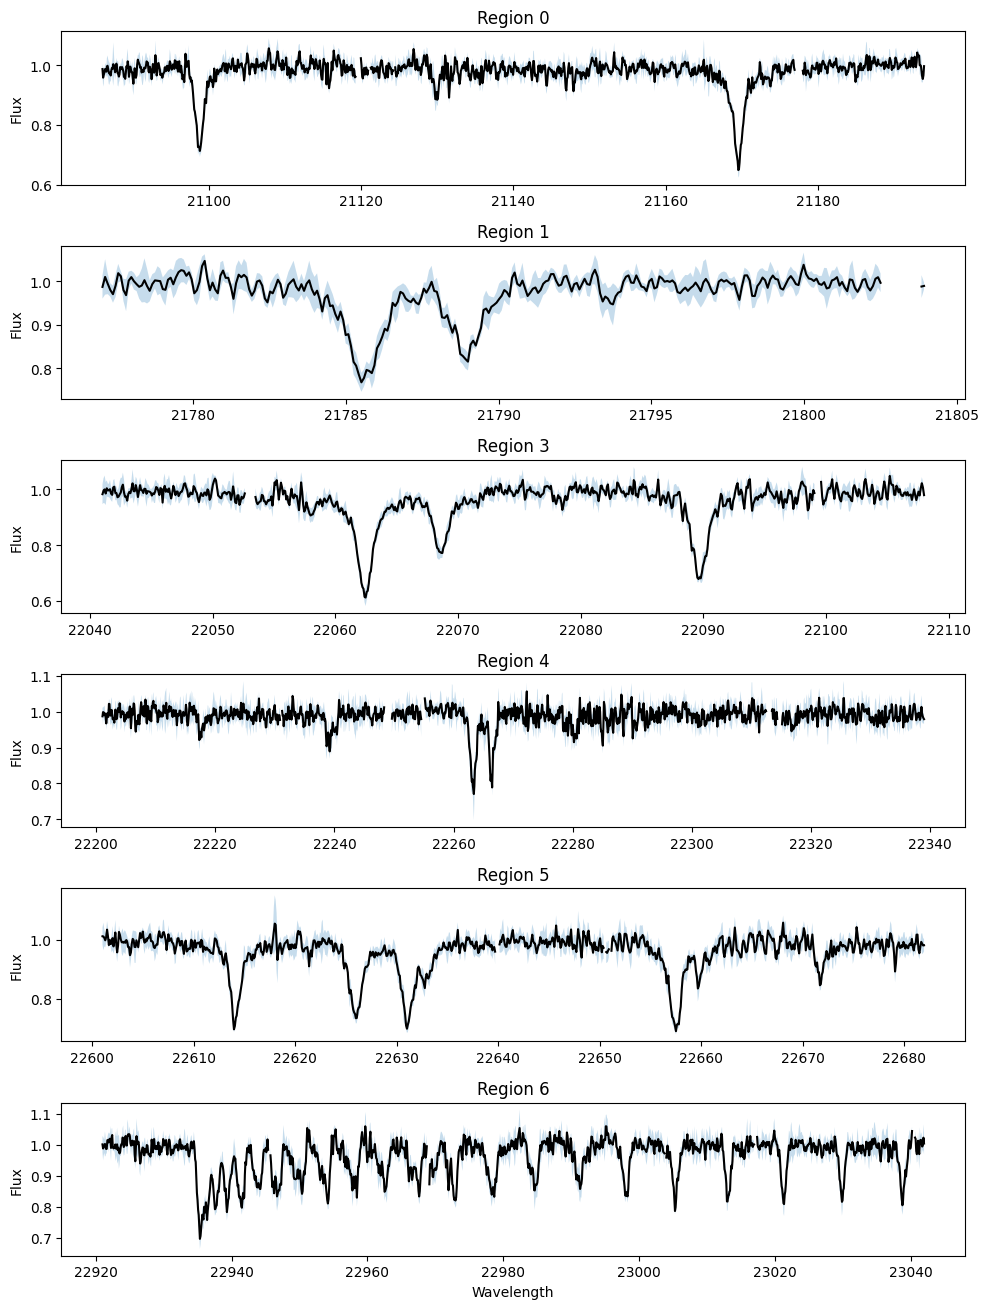

In [116]:
fig, axes = plt.subplots(len(testdata.regions), 1, figsize=(10, 2.2 * len(testdata.regions)))

if len(testdata.regions) == 1:
    axes = [axes]

for ax, r in zip(axes, testdata.regions):
    x, y, yerr = testdata.get_region(r)
    ax.plot(x, y, color="black")
    ax.fill_between(x, y - yerr, y + yerr, alpha=0.25)
    ax.set_title(f"Region {r}")
    ax.set_ylabel("Flux")

axes[-1].set_xlabel("Wavelength")
plt.tight_layout()
plt.show()

In [117]:
moognn = MoogStokesNN(nn_models_dir="data/", regions=range(7))

In [118]:
stage1_out = run_stage_raw(
    basename=basename,
    moognn=moognn,
    data_path=data_path,
    regions=[0, 1, 2, 3, 4, 5, 6],
    fixed_params={"rK": 0.0},                 # all 5 parameters free
    stage_label="no region 2",
    nwalkers=16,
    nsteps=1000,
    scale_discard=800,
    scale_thin=5,
)


[Nyquist sampling] Factor applied: 1. Old SNR = 39.26549299820269
[Nyquist sampling] Factor applied: 1. New SNR = 39.26549299820269


100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:23<00:00,  6.99it/s]


[yerr rescaled] Factor applied: 1.0457817550210362. Total scaling so far: 1.0457817550210362


100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [02:06<00:00,  7.90it/s]


4.477951714148773


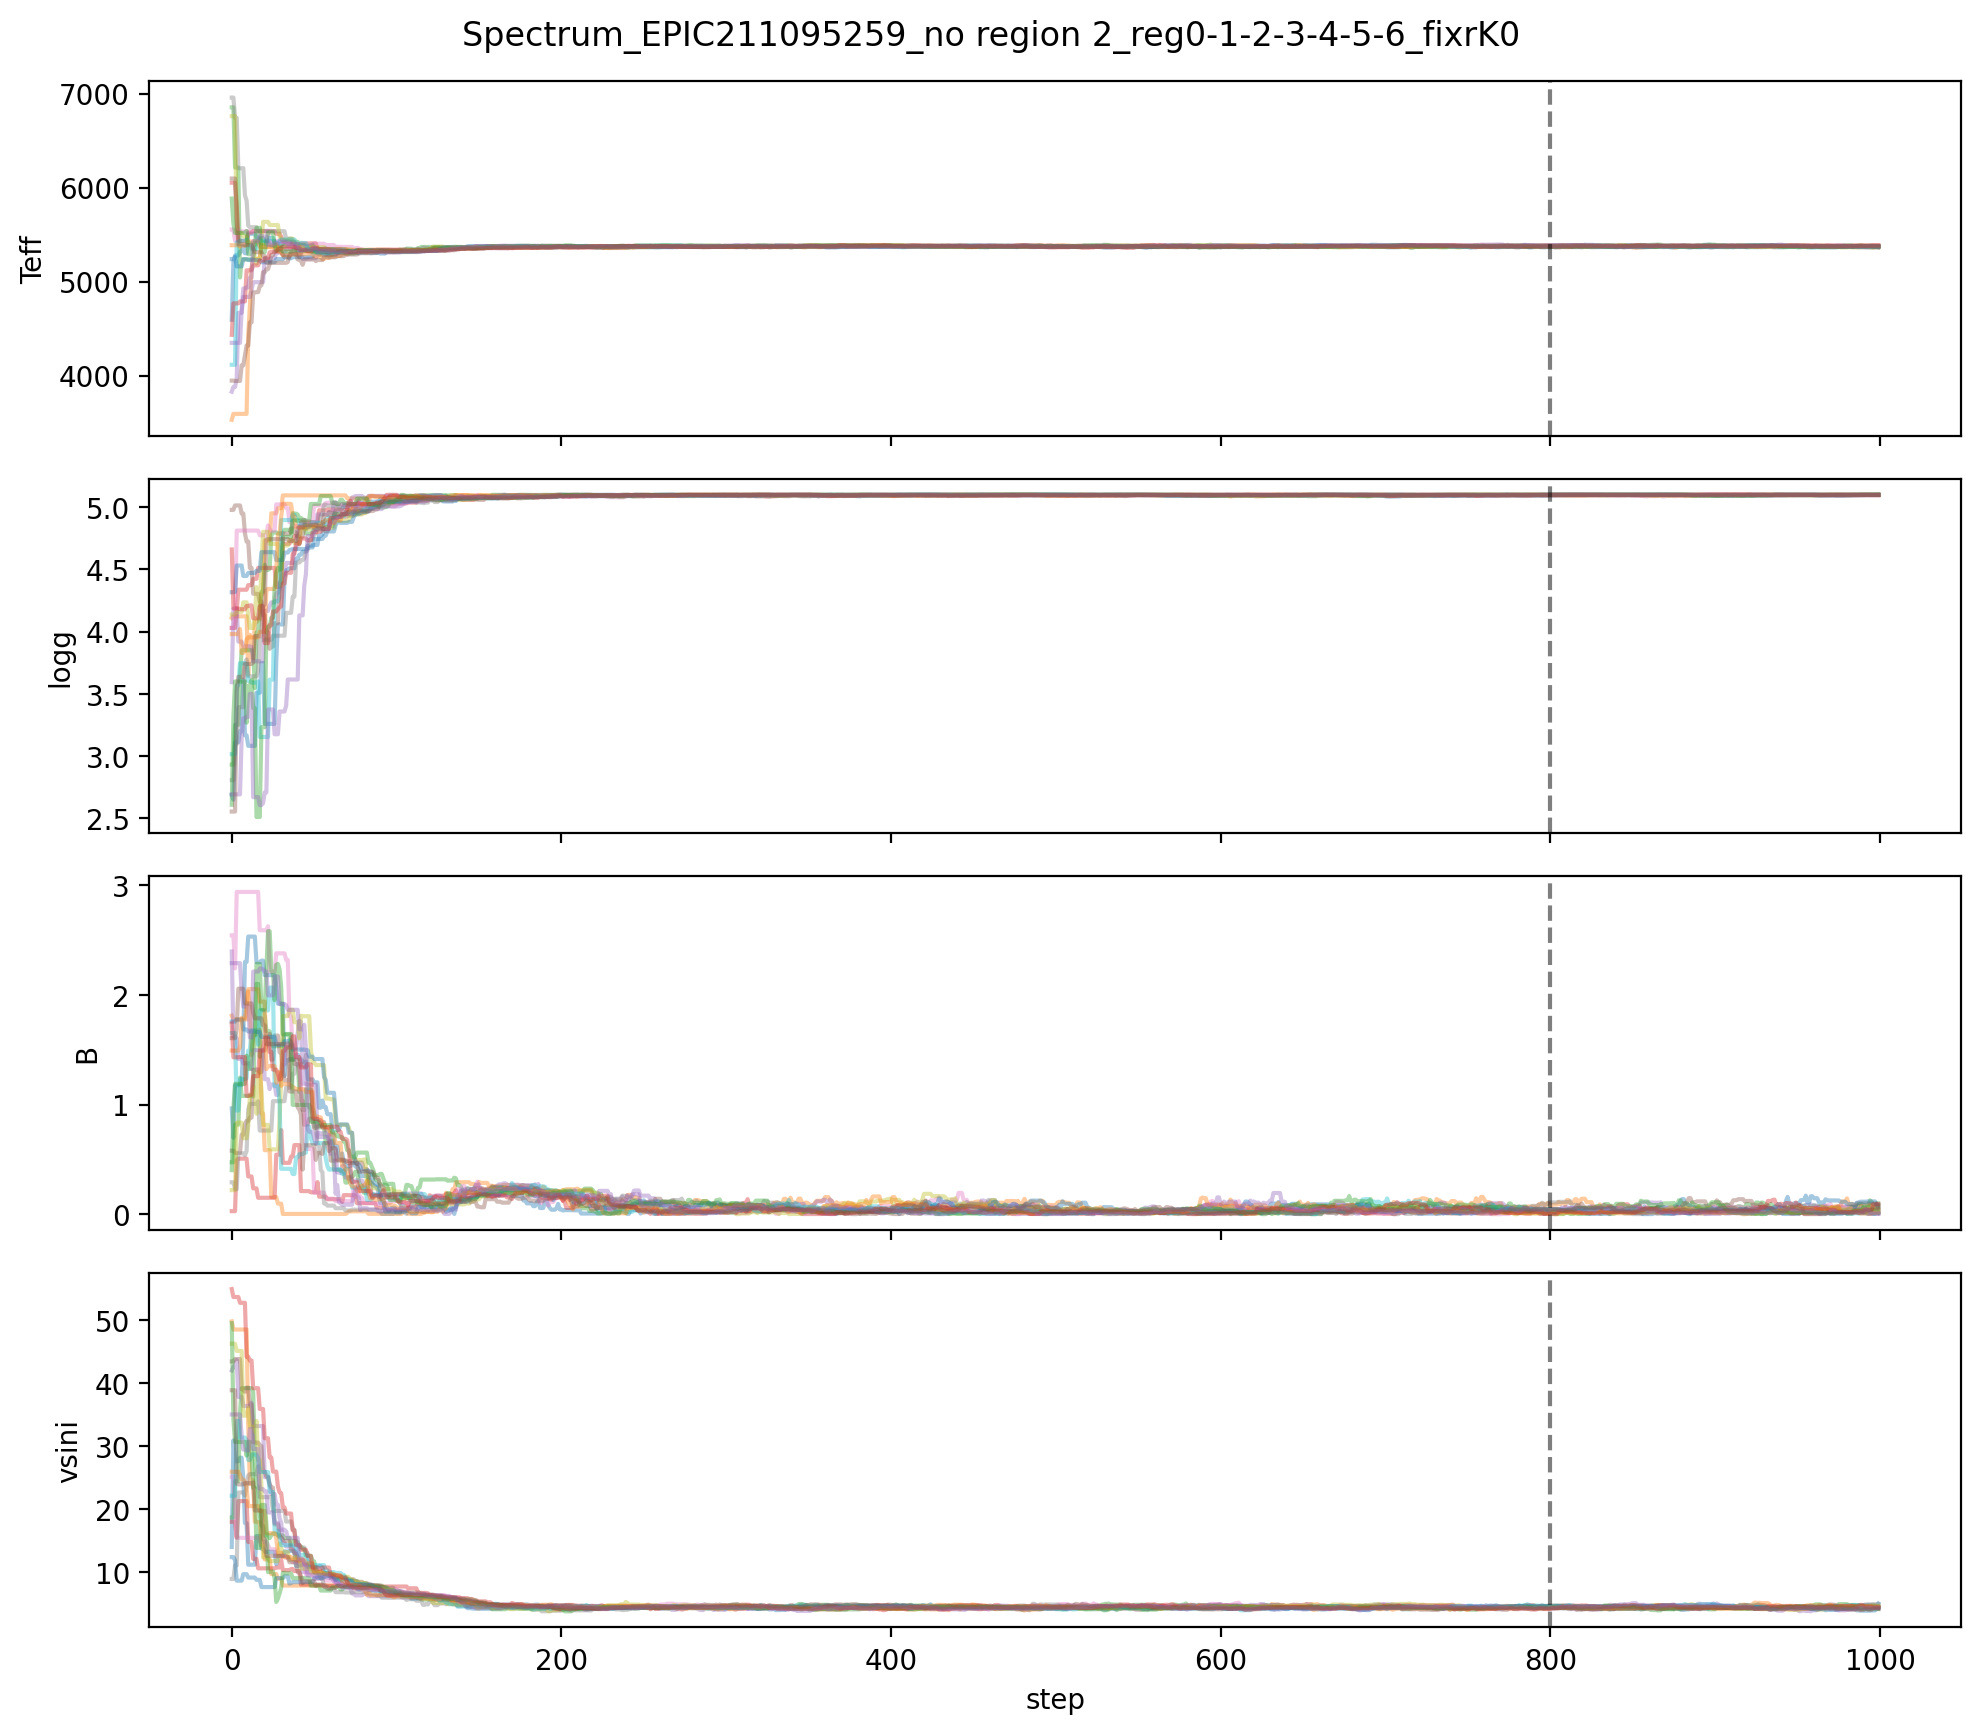

In [119]:
out1 = postprocess_stage_result(
    stage1_out,
    moognn=moognn,
    data_path=data_path,
    discard=800,
    thin=5,
)

vsini_stage1 = out1["values"]["vsini"]
print(vsini_stage1)

display(Image(out1["trace_plot"]))


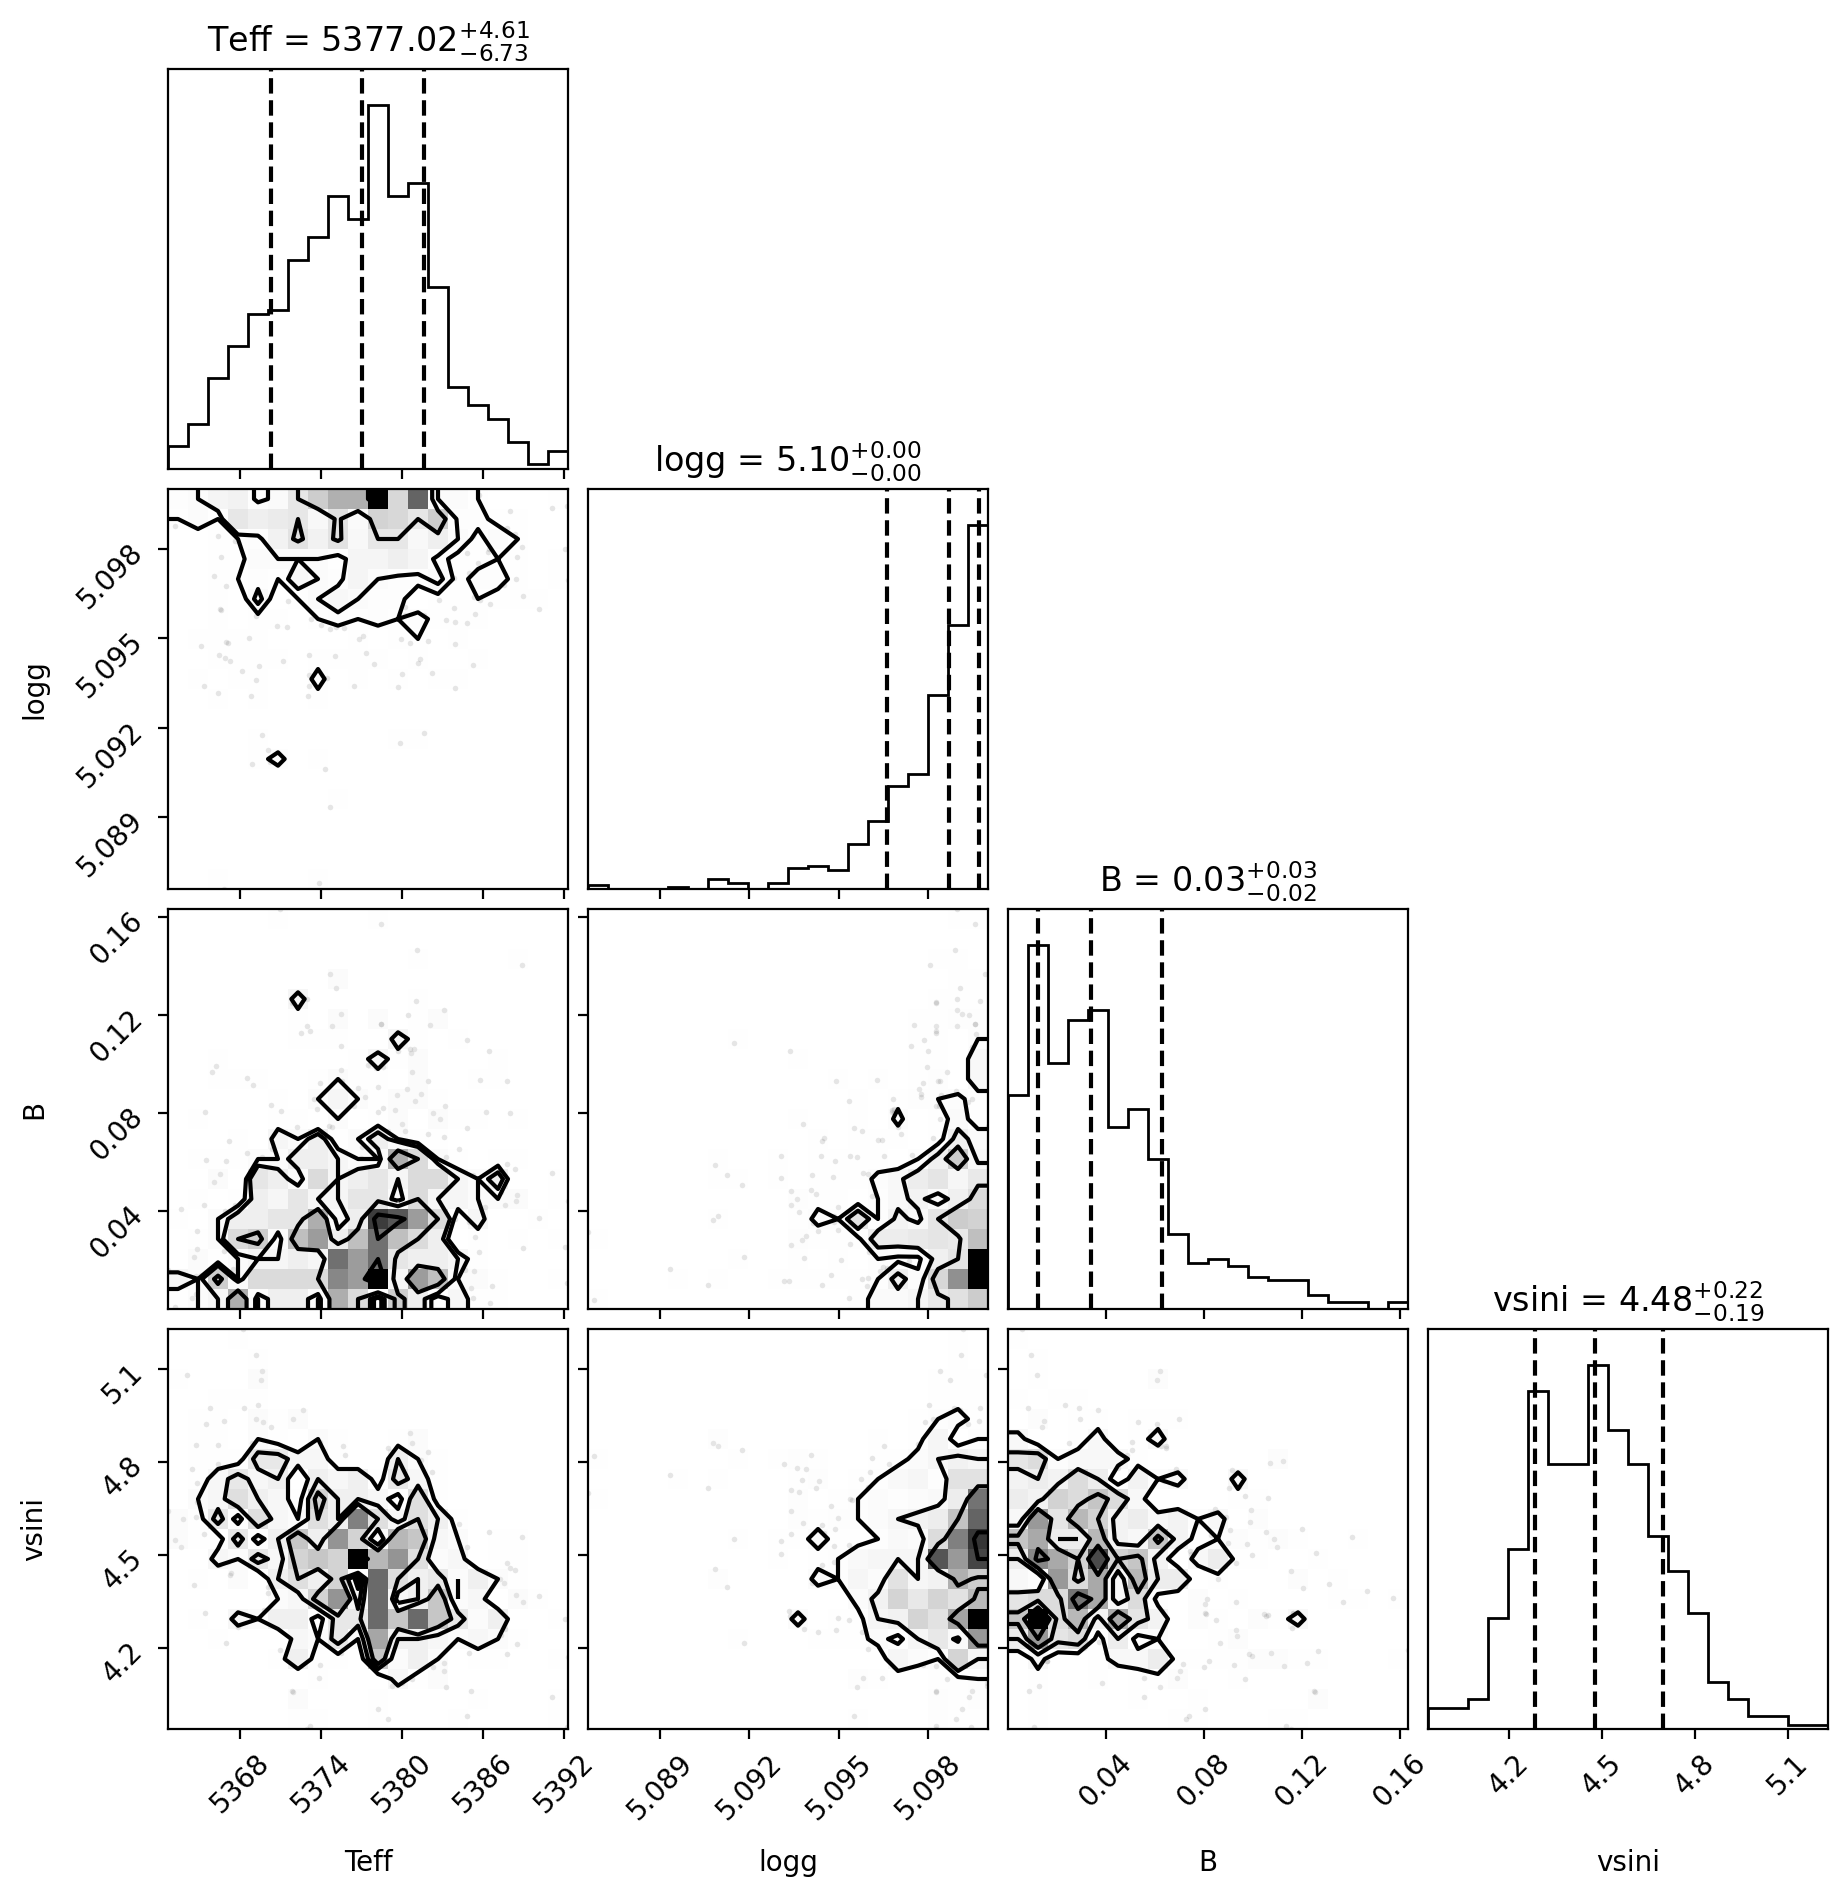

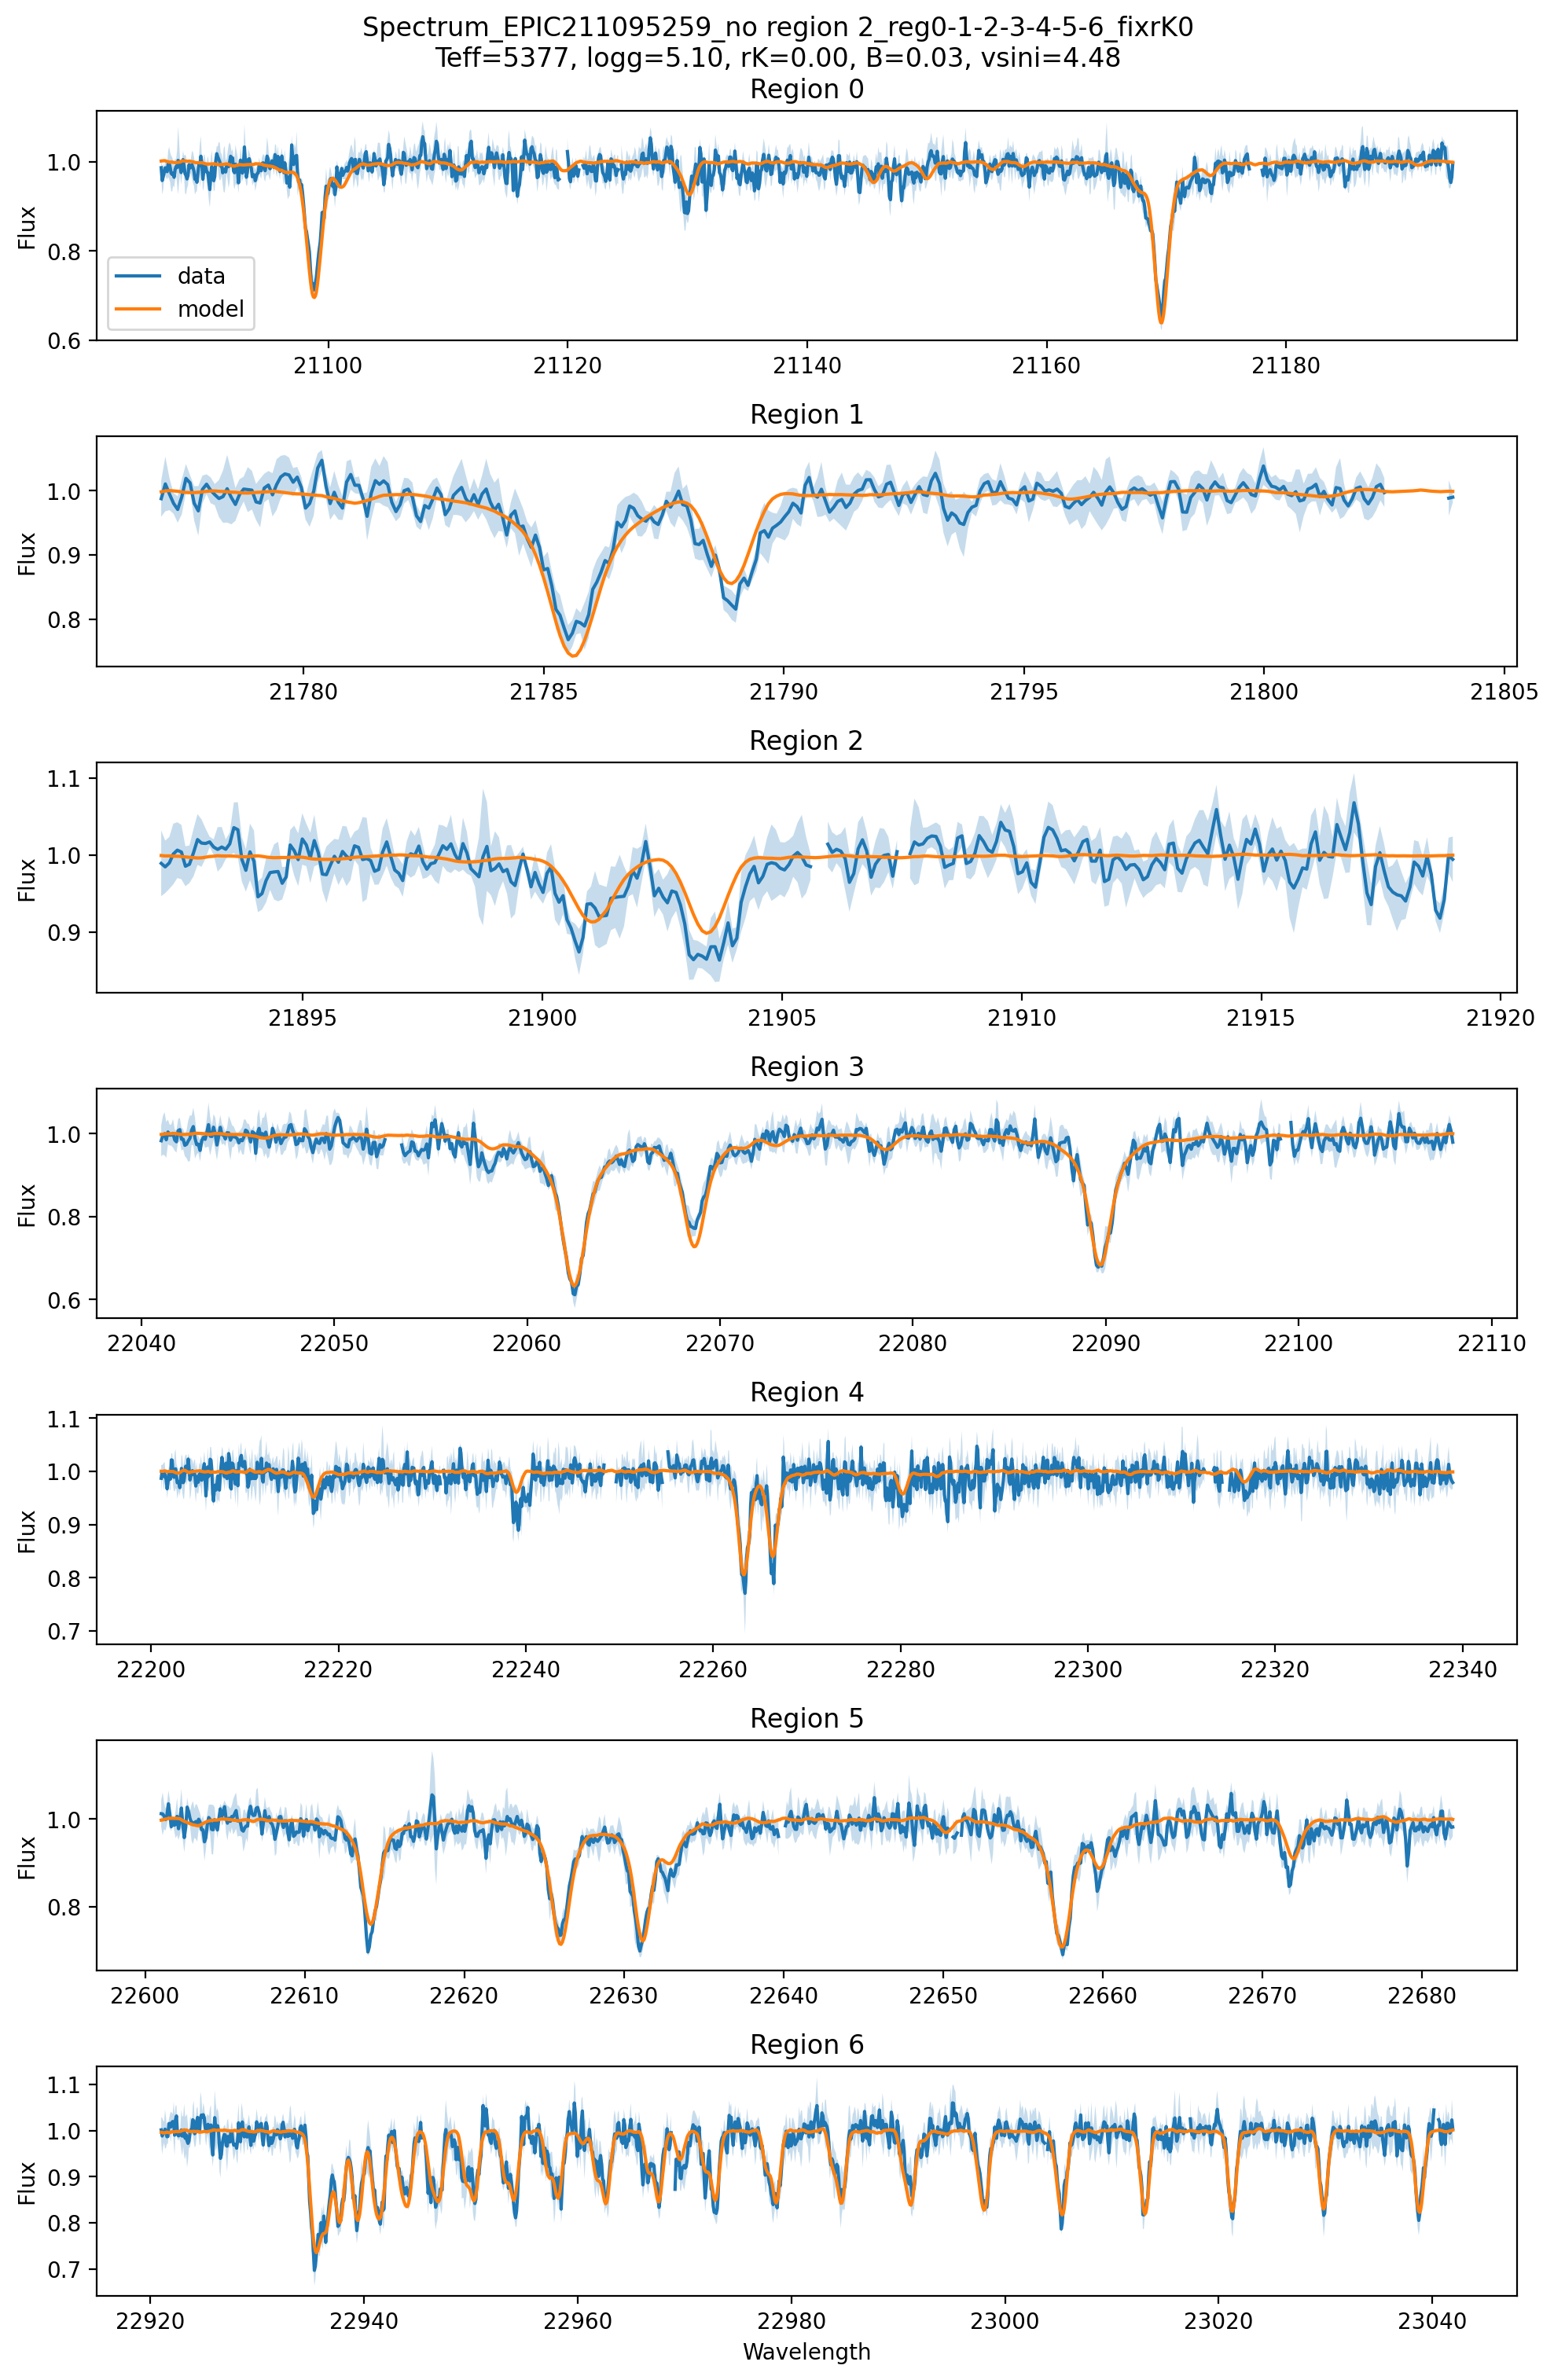

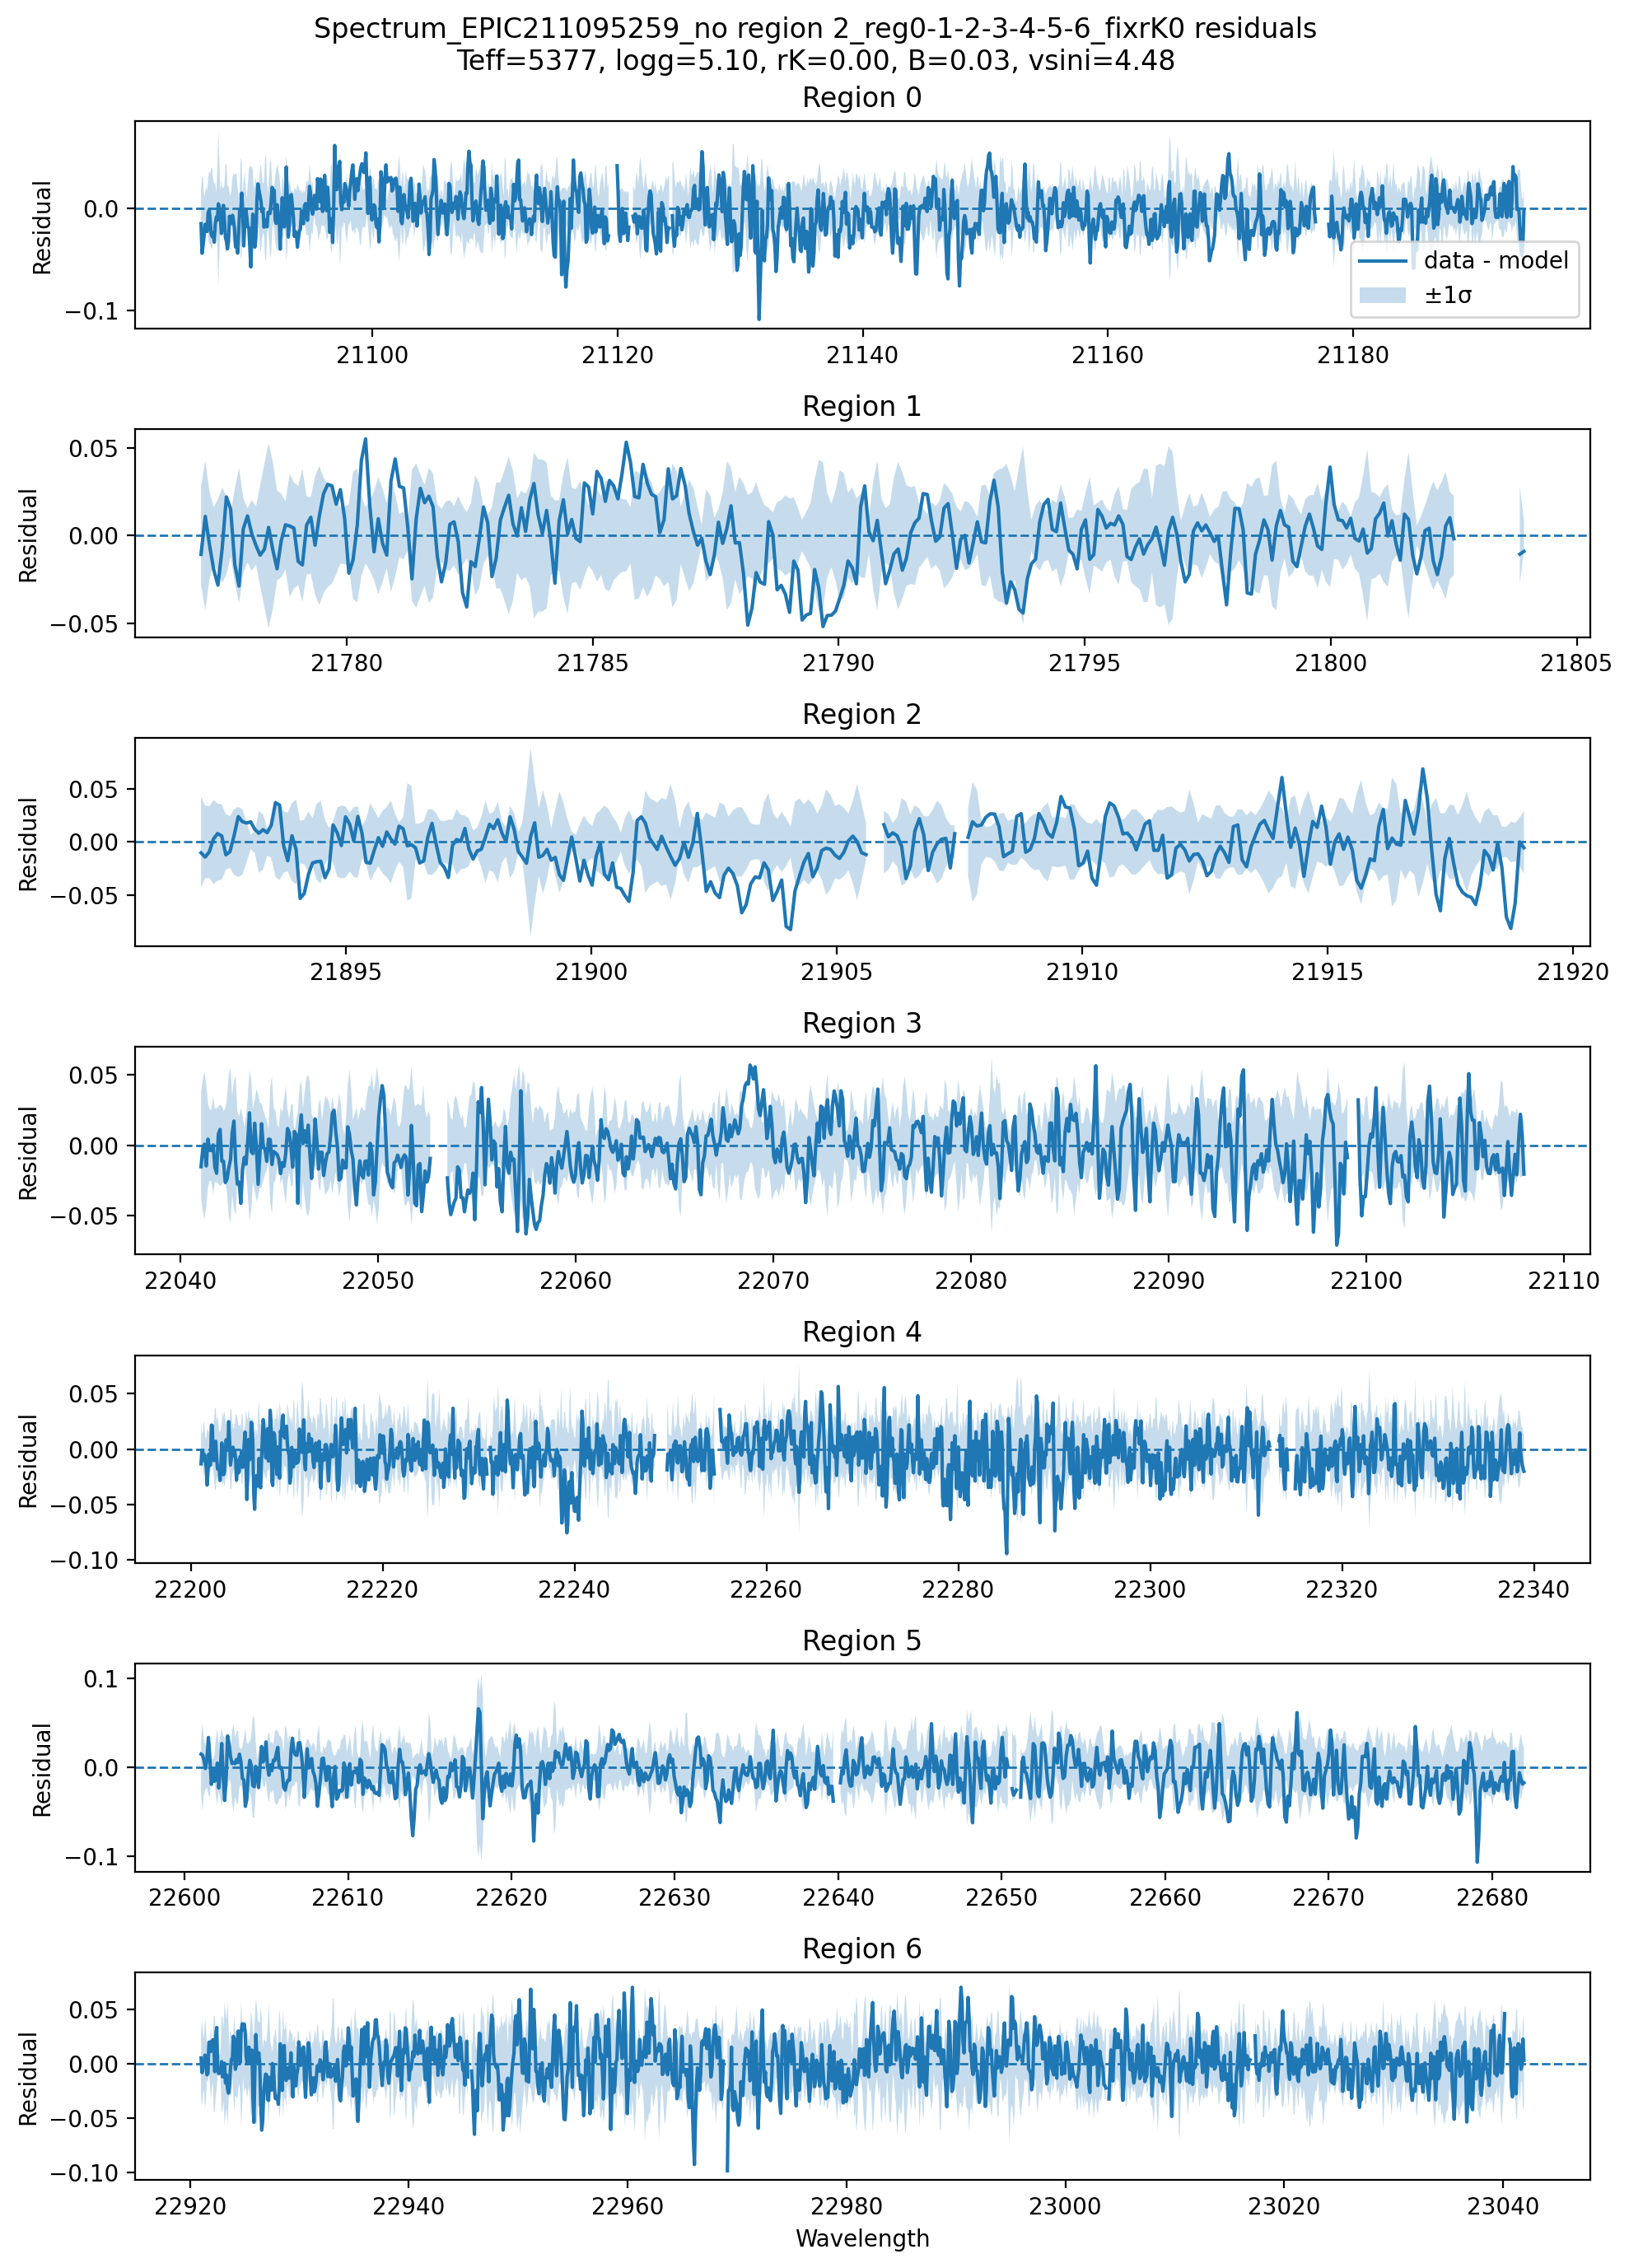

In [120]:
display(Image(out1["corner_plot"]))
display(Image(out1["bestfit_plot"]))
display(Image(out1["residual_plot"]))


In [121]:
stage2_out = run_stage_raw(
    basename=basename,
    moognn=moognn,
    data_path=data_path,
    regions=[0, 1, 2, 3, 4, 5],
    fixed_params={"vsini": vsini_stage1, "rK": 0.0},
    stage_label="stage2_subset_fixed_vsini",
    nwalkers=16,
    nsteps=1000,
    scale_discard=800,
    scale_thin=5,
)

[Nyquist sampling] Factor applied: 1. Old SNR = 39.26549299820269
[Nyquist sampling] Factor applied: 1. New SNR = 39.26549299820269


100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:42<00:00,  9.76it/s]


[yerr rescaled] Factor applied: 1.067157258883041. Total scaling so far: 1.067157258883041


100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:44<00:00,  9.55it/s]


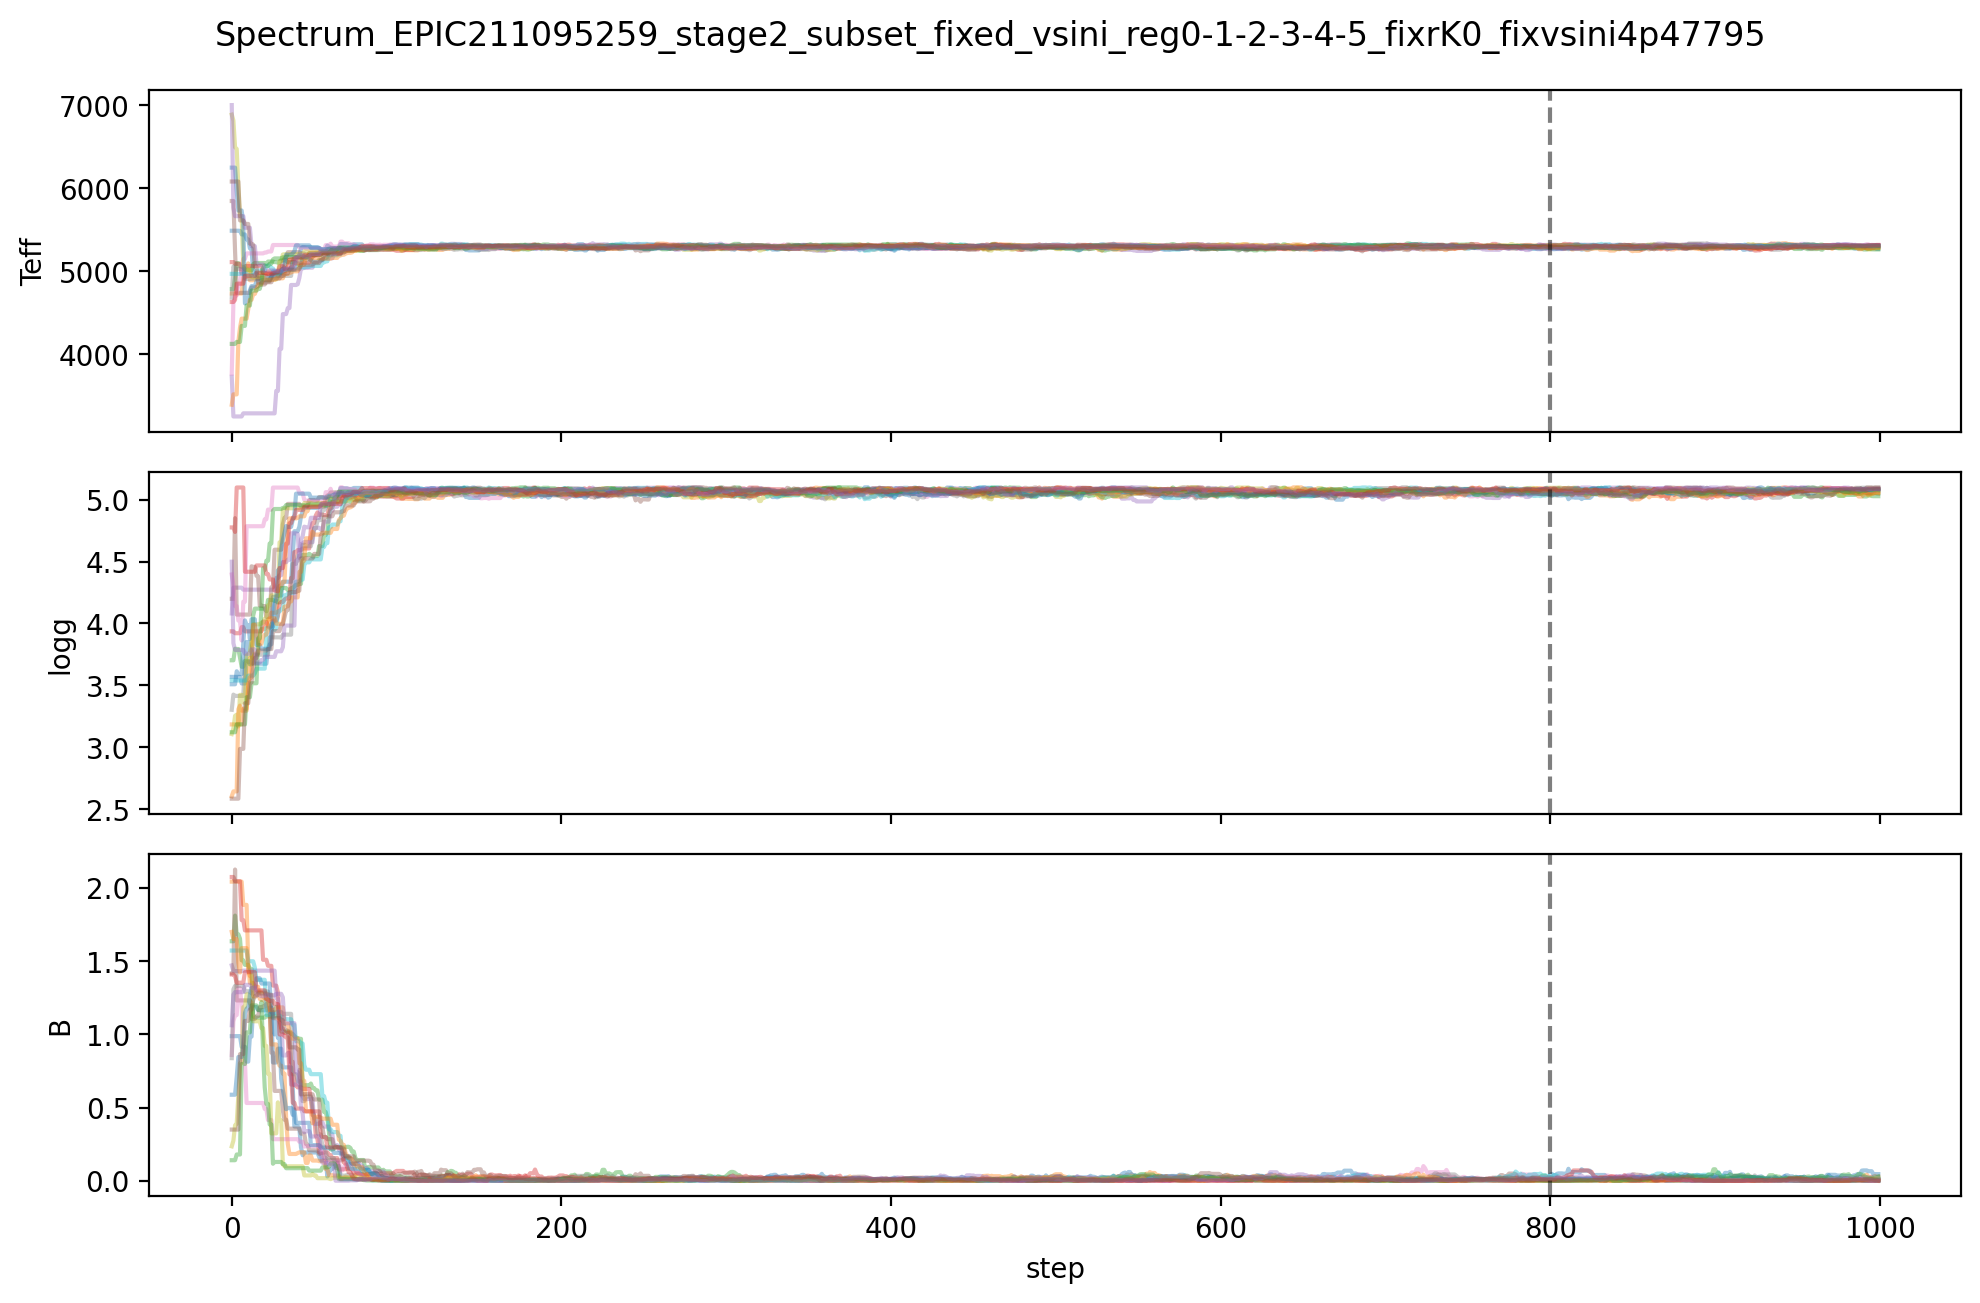

In [122]:
out2 = postprocess_stage_result(
    stage2_out,
    moognn=moognn,
    data_path=data_path,
    discard=800,
    thin=5,
)

display(Image(out2["trace_plot"]))


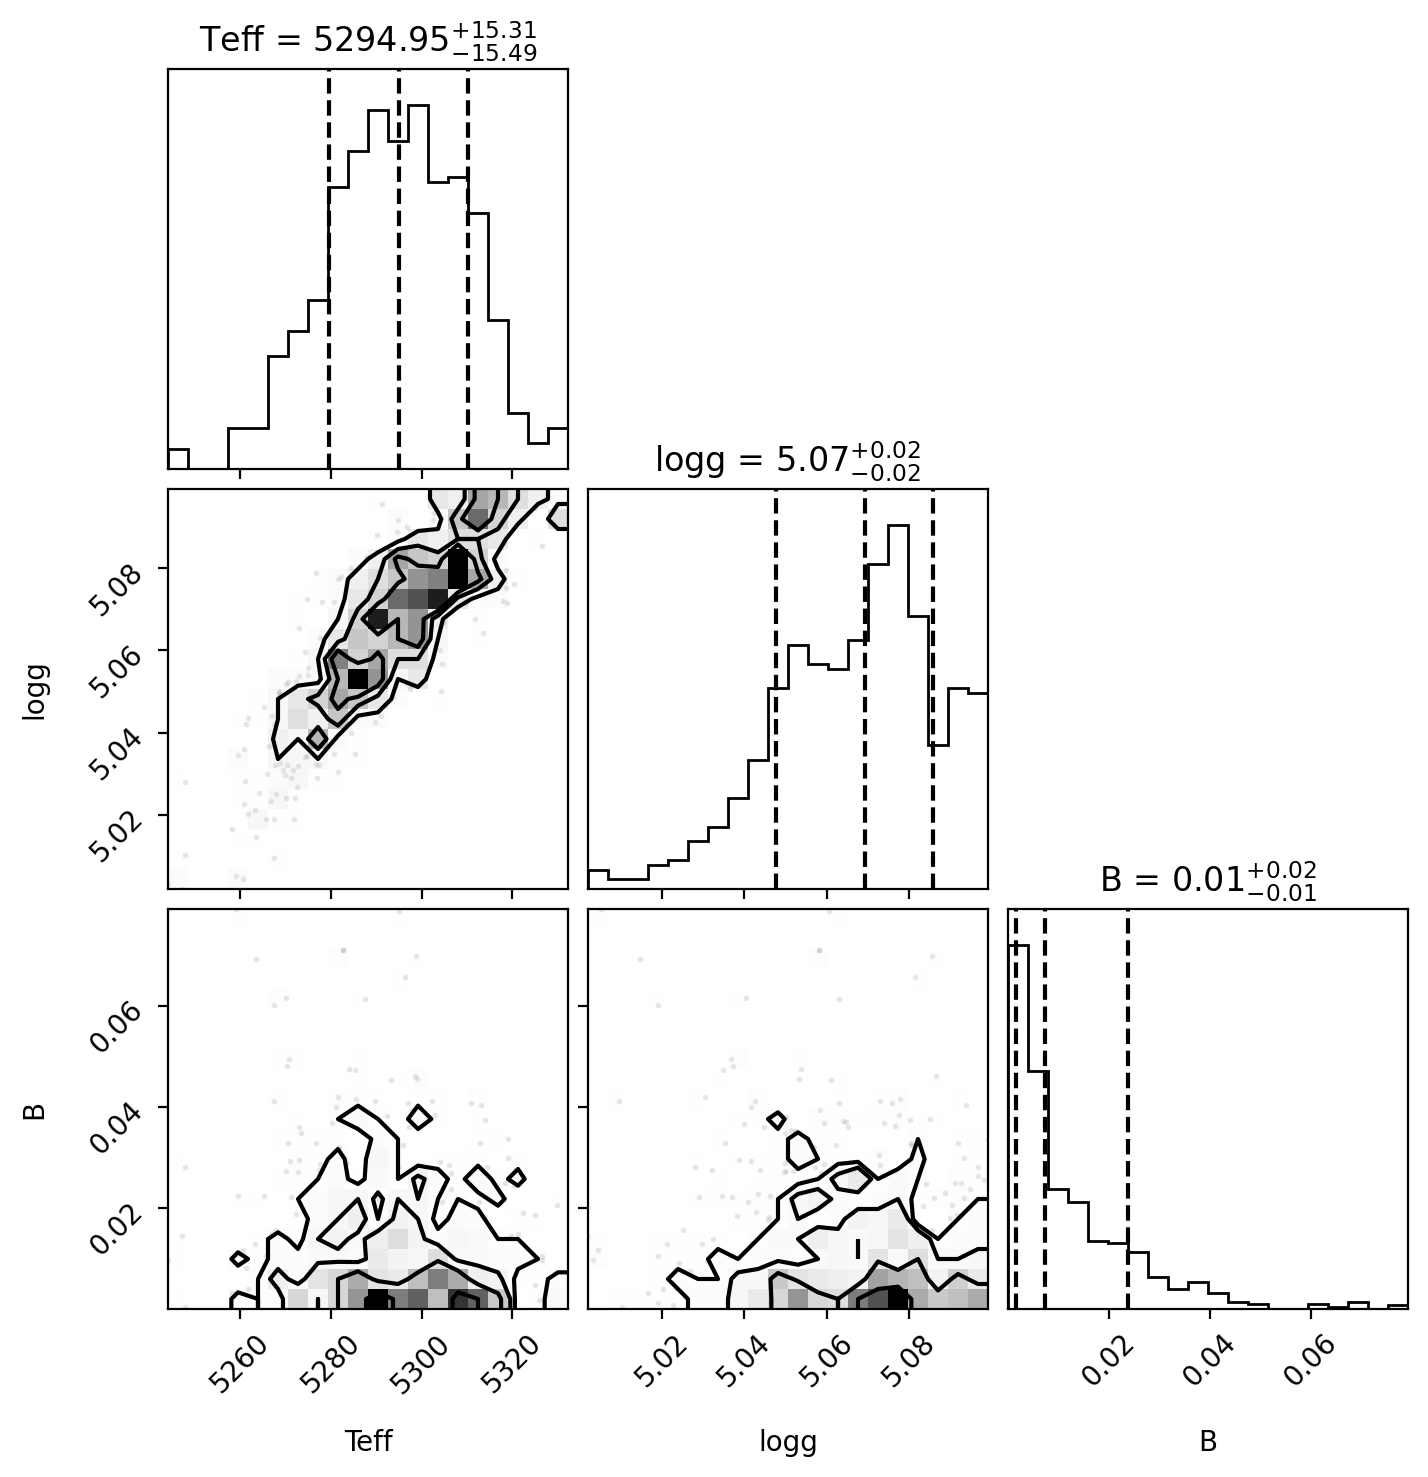

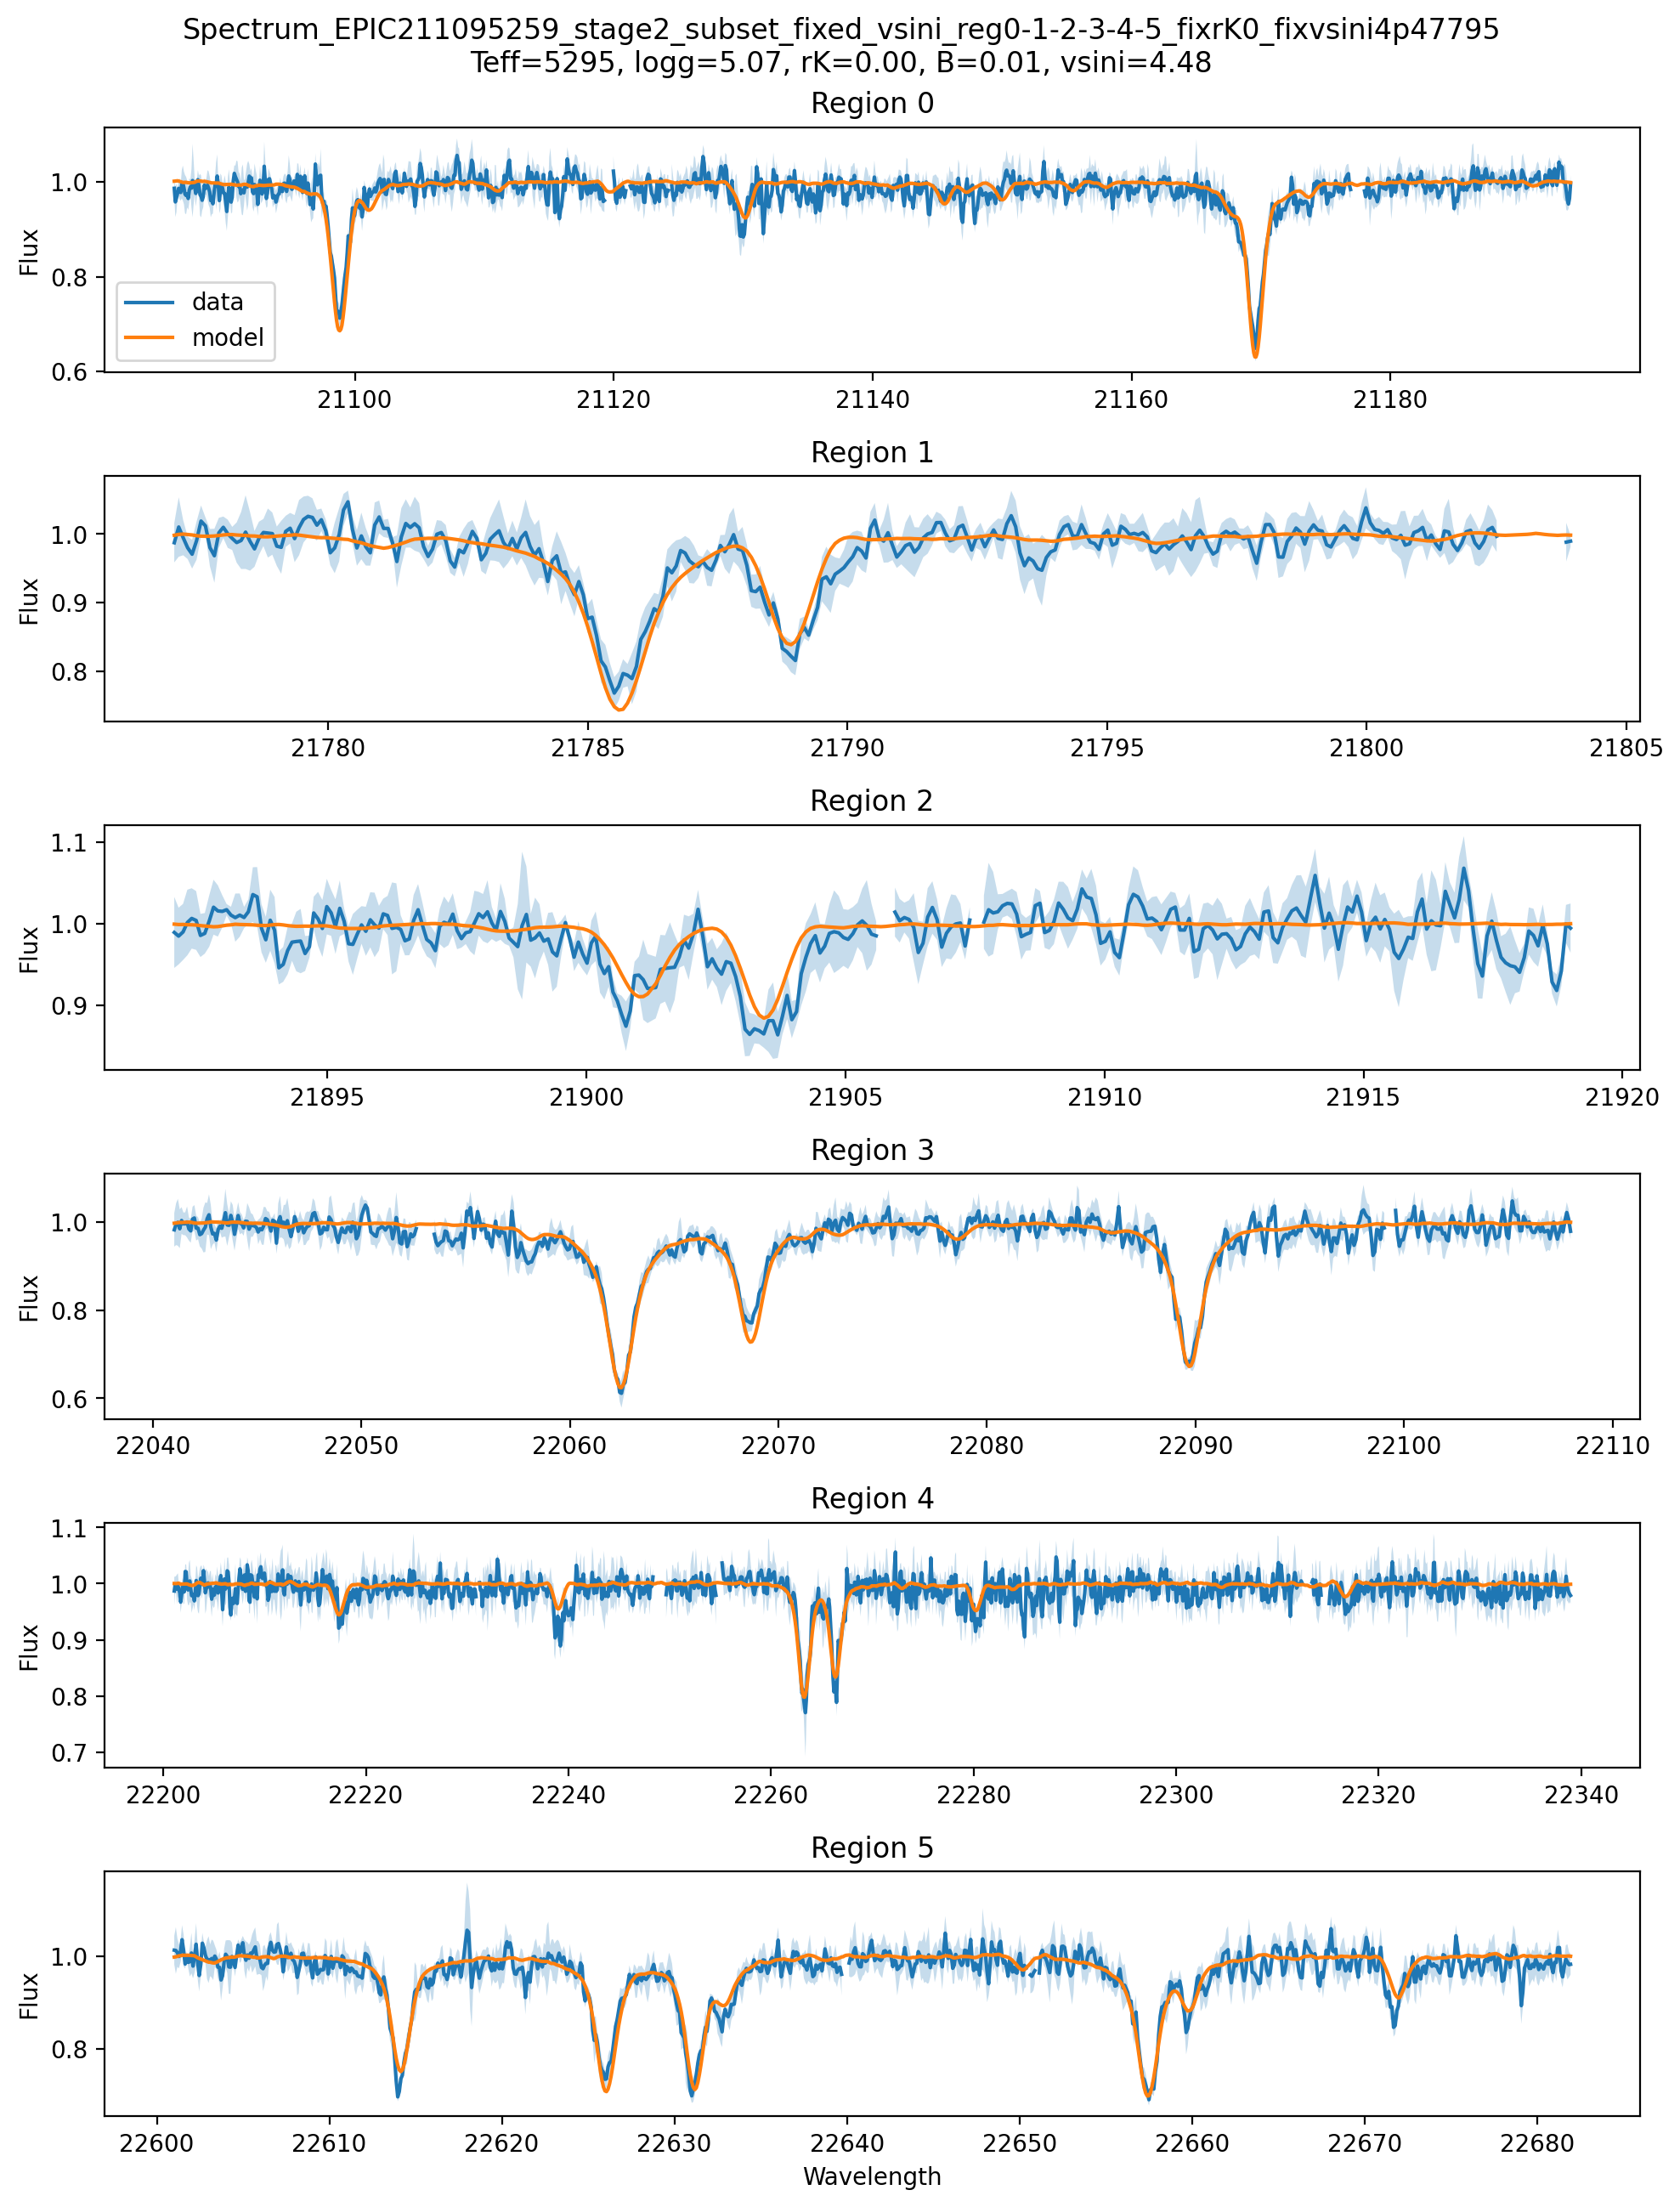

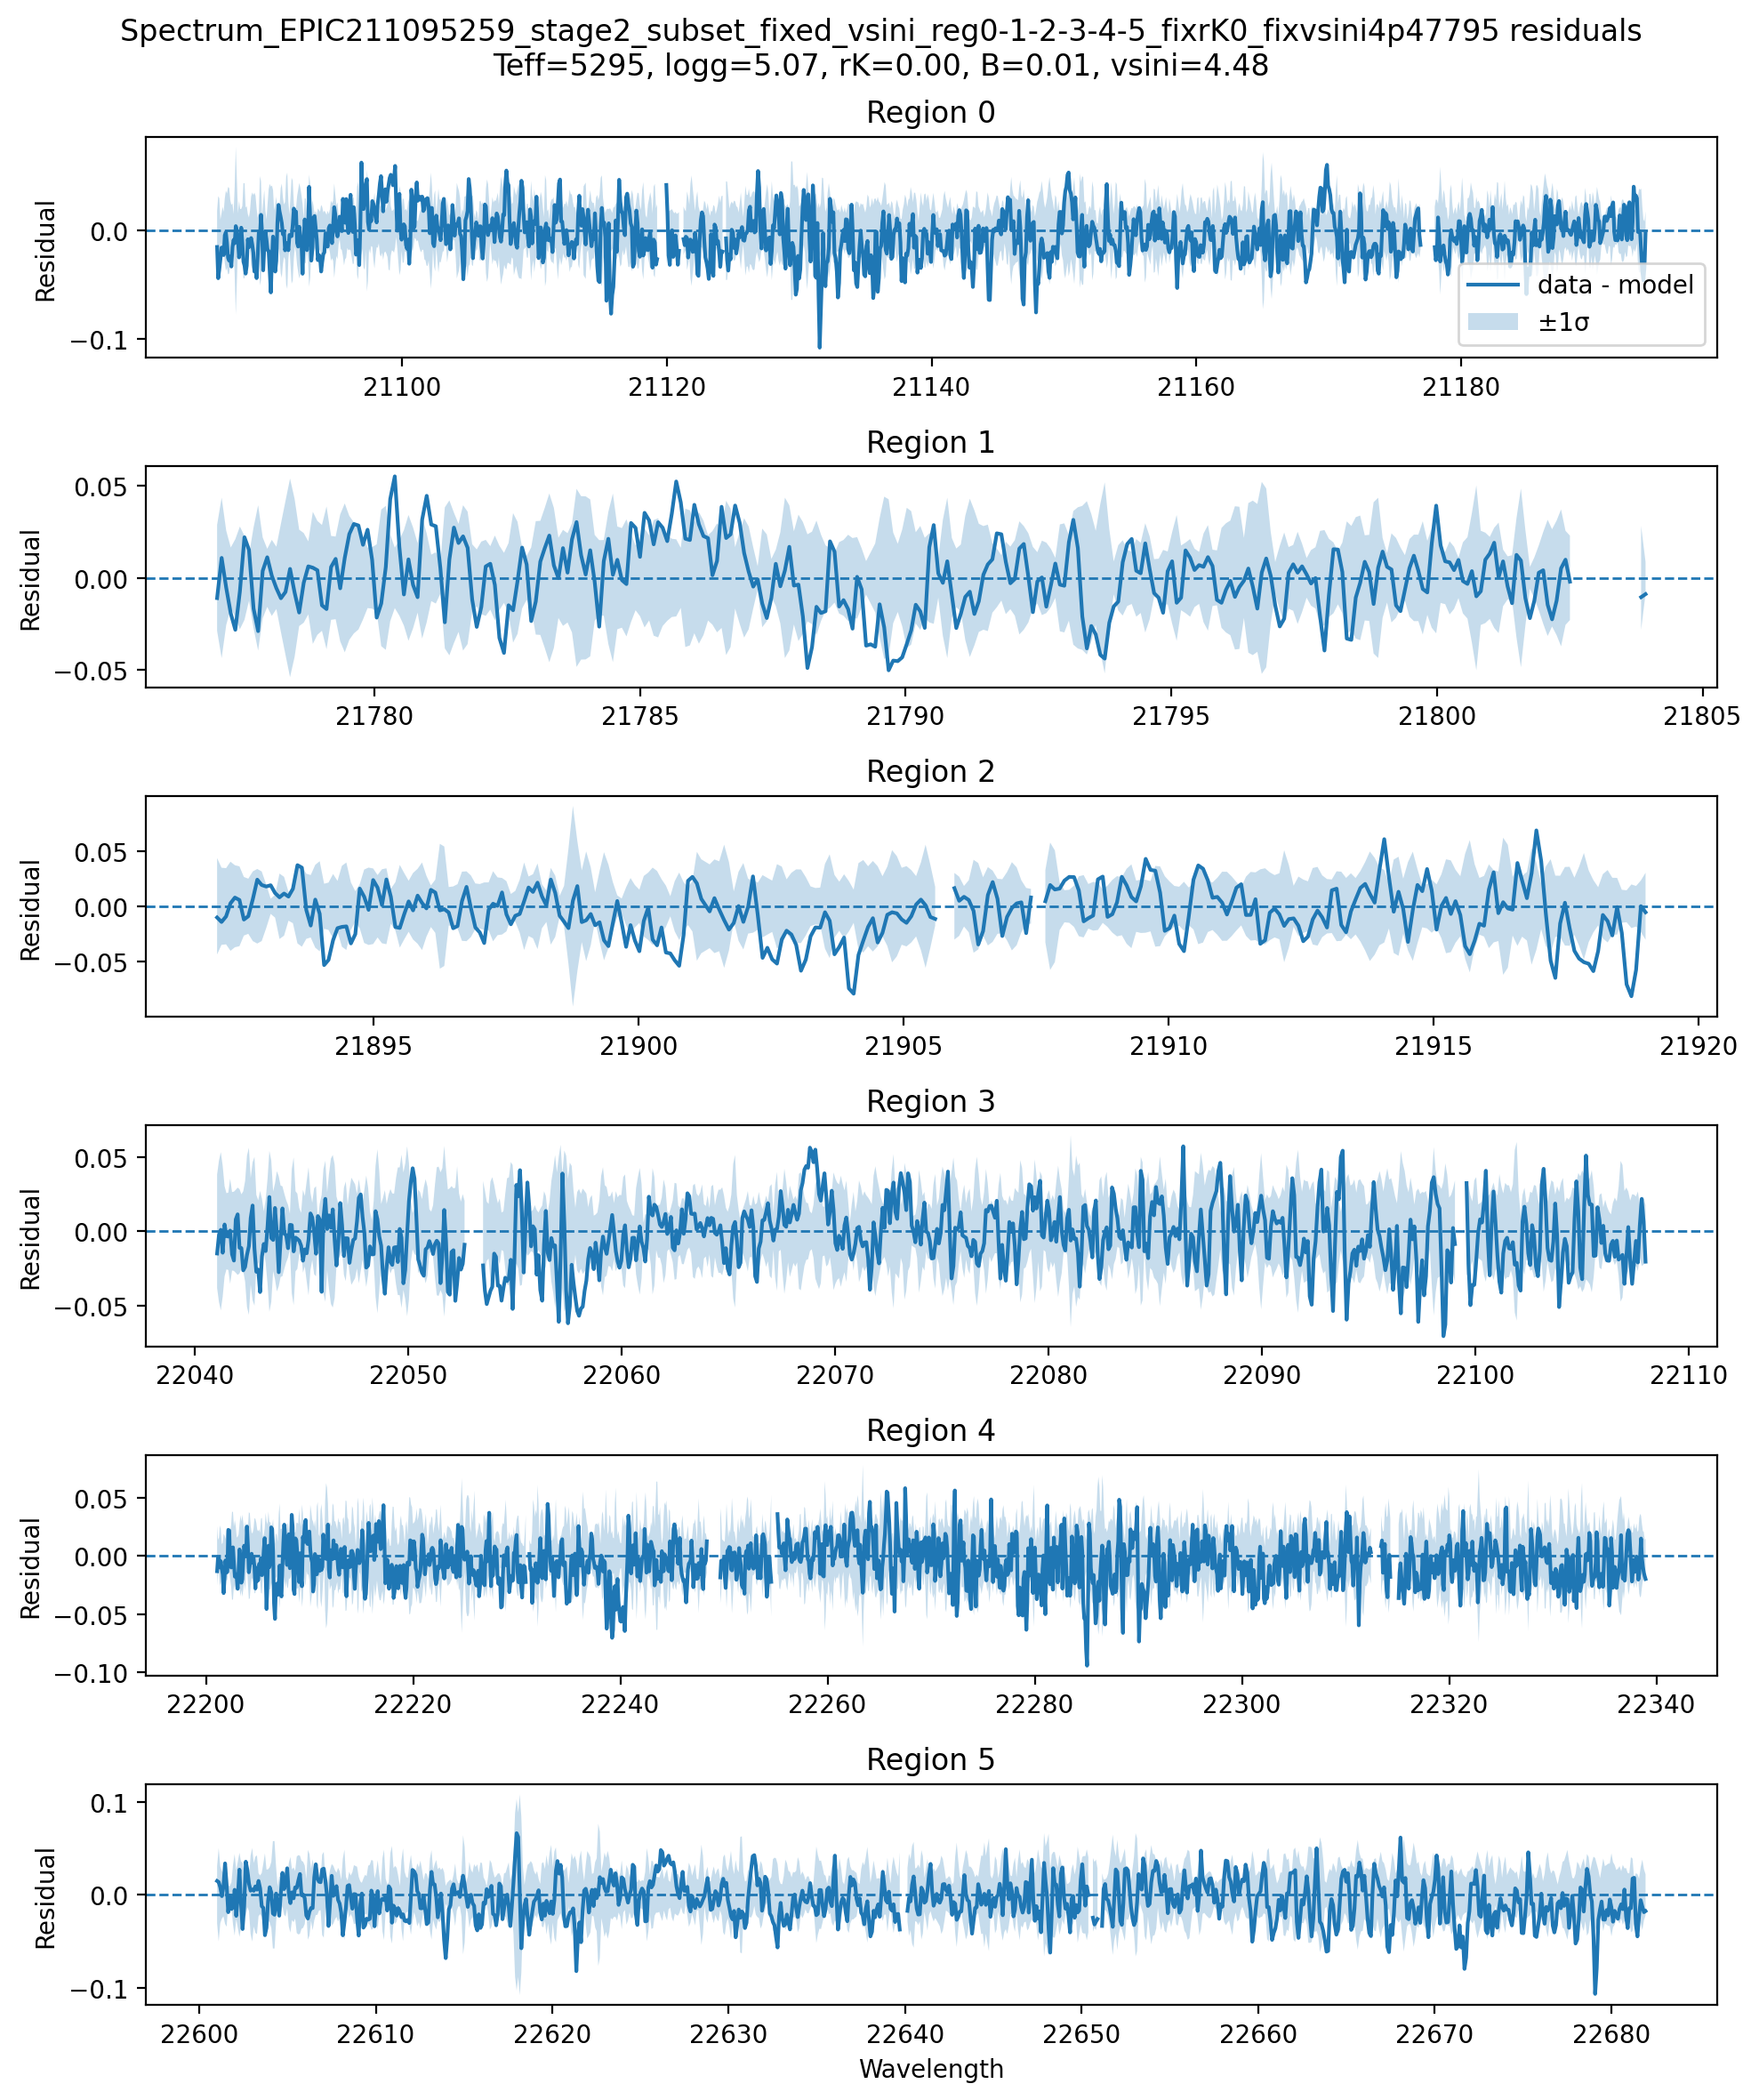

In [123]:
display(Image(out2["corner_plot"]))
display(Image(out2["bestfit_plot"]))
display(Image(out2["residual_plot"]))
